# 🧪 Taller - Evaluando la Creatividad Artificial: Métricas y Reflexión

## 🔧 Instalar librerías necesarias

In [1]:
!pip install diffusers transformers accelerate clip-anytorch ftfy scipy --upgrade
!pip install git+https://github.com/openai/CLIP.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3


## 📦 Importar librerías

In [8]:
import torch
from diffusers import StableDiffusionPipeline
import clip
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim
import cv2

## 📌 Configuración

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
prompt = "A futuristic library floating in the sky, filled with glowing books and digital scrolls, in the style of a dreamlike painting"
seeds = [0, 42, 99, 2025]
num_inference_steps = 40
guidance_scale = 7.5
os.makedirs("imagenes_generadas", exist_ok=True)

## 🚀 Cargar modelo de difusión

In [4]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

## 🎨 Generar imágenes

In [5]:
image_paths = []
for seed in seeds:
    generator = torch.Generator(device=device).manual_seed(seed)
    image = pipe(prompt, num_inference_steps=num_inference_steps, guidance_scale=guidance_scale, generator=generator).images[0]
    filename = f"biblioteca_{seed}.png"
    image.save(f"imagenes_generadas/{filename}")
    image_paths.append((seed, f"imagenes_generadas/{filename}"))

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]


## 🤖 Evaluar con CLIP

In [6]:
model, preprocess = clip.load("ViT-B/32", device=device)
text_token = clip.tokenize([prompt]).to(device)

clip_scores = []

for seed, img_path in image_paths:
    img = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(img)
        text_features = model.encode_text(text_token)
        similarity = torch.cosine_similarity(image_features, text_features).item()
    clip_scores.append({"image": f"biblioteca_{seed}.png", "clip_score": round(similarity, 4)})

100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 49.0MiB/s]


## Evaluar simetría

In [10]:
def calcular_simetria(path_imagen):
    img = cv2.imread(path_imagen)
    img = cv2.resize(img, (512, 512))  # asegurar mismo tamaño
    mitad = img.shape[1] // 2
    izquierda = img[:, :mitad]
    derecha = img[:, mitad:]
    derecha_invertida = cv2.flip(derecha, 1)  # reflejar horizontalmente
    score, _ = ssim(izquierda, derecha_invertida, full=True, channel_axis=-1)

    return round(score, 4)

# Evaluar todas las imágenes
for entry in clip_scores:
    img_path = f"imagenes_generadas/{entry['image']}"
    entry["symmetry_score"] = calcular_simetria(img_path)


## 📊 Mostrar resultados

In [11]:
df_final = pd.DataFrame(clip_scores)
df_final = df_final.sort_values(by="clip_score", ascending=False).reset_index(drop=True)
display(df_final)

,image,clip_score,symmetry_score
0,biblioteca_42.png,0.3254,0.1509
1,biblioteca_99.png,0.3252,0.3502
2,biblioteca_2025.png,0.3208,0.2130
3,biblioteca_0.png,0.3203,0.0300


## 🖼️ Mostrar imágenes con scores

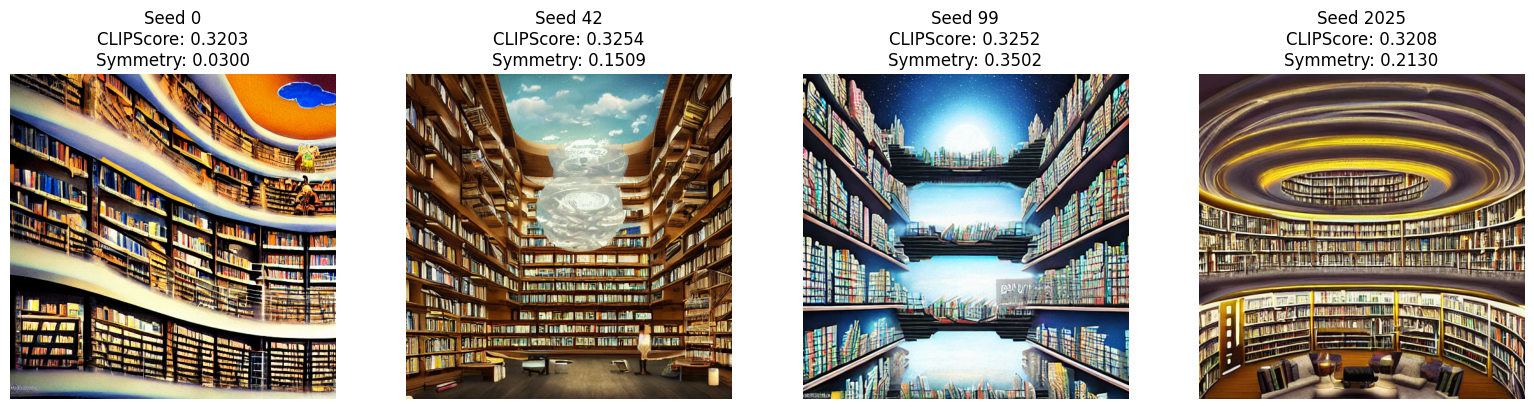

In [14]:
fig, axes = plt.subplots(1, len(image_paths), figsize=(16, 4))
for i, (seed, img_path) in enumerate(image_paths):
    img = Image.open(img_path)
    clip = clip_scores[i]['clip_score']
    symm = clip_scores[i]['symmetry_score']
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Seed {seed}\nCLIPScore: {clip:.4f}\nSymmetry: {symm:.4f}")
plt.tight_layout()
plt.show()


## Guardar resultados

In [13]:
os.makedirs("resultados_metricas", exist_ok=True)
# Guardar resultados en CSV
df_final.to_csv("resultados_metricas/metricas_clip_simetria.csv", index=False)